In [1]:
import astropy.constants as const
from astropy.cosmology import Planck18
import astropy.units as u
import corner
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pickle
from scipy.stats import poisson
import yaml


import zombie_rate as rate
import PTA as pta_utils
import smbhbs
import style.fig_style as fig_style
import utils
from binary_pop_model import analytic_hc2, getdndlogMcr, smbhb_density

# Load configs

In [2]:
# Load the population models config file
config_file = "./config/fig_config.yaml"

# Load the different configs
run_config, _ = utils.load_configs(config_file)

config_file = f"./config/binary_models/pop_models_1.2.yaml"
with open(config_file, 'r') as file:
    pop_config = yaml.safe_load(file)

# Randomness of the extrinsic zombie parameters
rng = np.random.default_rng(seed=run_config['seed'])

# The Earth term orbital frequency threshold (from NANOGrav upper bound)
fth = run_config['fth'] * u.Hz

# Load population models

In [3]:
### Define binary population models
pop_models = pop_config['models']
Nmodels = len(pop_models)

for i, pop_model in enumerate(pop_models):
    # Convert n0_dot to correct dimensions
    pop_model['n0_dot'] /= (u.Gyr * u.Mpc ** 3)

## Rescale $\dot{n}_0$ (if needed) to have correct $h_{\rm c}(f=1/yr)$

In [4]:
## Derive their respective n0_dot to have hc(fyr) = 3e-15
fyr = (1 / u.yr).to(u.Hz)

bounds = pop_config['bounds']

for i, pop_model in enumerate(pop_models):
    # Compute the reference characteristic strain at f = 1/yr for this population model
    hc_ref = np.sqrt(analytic_hc2(f=fyr, 
                                  smbhb_density=smbhb_density, 
                                  model=pop_model, 
                                  xi_I_bounds=bounds))
    
    # Check that the model is compatible with PTA observations
    if not np.allclose(hc_ref, run_config['hc_ref'], rtol=5e-3):
        # Compute the scaling factor for n0_dot to obtain hc(1/yr) = 2e-15 (compatible with PTA results)
        n0dot_factor = (run_config['hc_ref'] ** 2 / hc_ref ** 2).to(u.dimensionless_unscaled)

        # Update the n0dot of the model
        pop_model['n0_dot'] *= n0dot_factor

        print(f"Model {i+1} n·_0 = {pop_model['n0_dot']:.2e} \
                in log_10 => {np.log10(pop_model['n0_dot'].value)}")

# Paper plots

## Comoving merger density

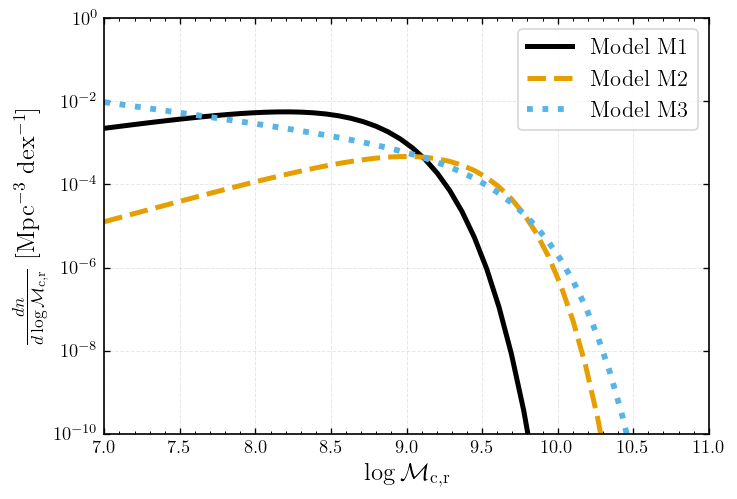

In [5]:
log10_Mcr_s = np.linspace(bounds['log10_Mcr_min'], bounds['log10_Mcr_max'], 50)
lss = ['solid', '--', 'dotted']
lws = [3, 3, 3.5]

for ip, pop_model in enumerate(pop_models):
    dndlogMcr = getdndlogMcr(log10_Mcr=log10_Mcr_s, pop_model=pop_model,
                             z_min=bounds['z_min'], z_max=bounds['z_max'])
    
    plt.semilogy(log10_Mcr_s, dndlogMcr, lw=lws[ip], ls=lss[ip], label=f"Model {pop_model['name']}")
plt.xlabel(r"$\log \mathcal{M}_{\rm c, r}$", fontsize=15)
plt.ylabel(r"$\frac{d n}{d\log \mathcal{M}_{\rm c, r}}$ [Mpc$^{-3}$ dex$^{-1}$]", fontsize=15)
plt.xlim([bounds['log10_Mcr_min'], bounds['log10_Mcr_max']])
plt.ylim([1e-10, 1])
plt.legend(fontsize=13.5)
plt.savefig('./plots/merger_density_Mcr.png')
plt.savefig('./plots/merger_density_Mcr.pdf')
plt.show()

## $f_{\rm orb}^{(P),a}$

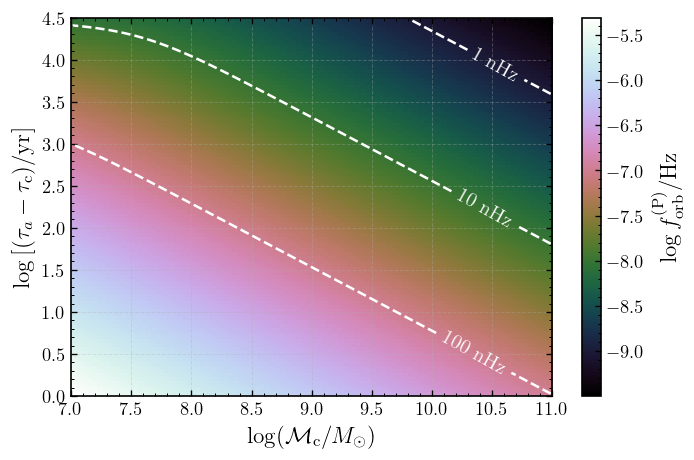

In [6]:
# Range of time delay and observer frame chirp mass
log_Dtau_tot_s = np.linspace(0, 4.5, 150)
Dtau_tot_s = 10 ** log_Dtau_tot_s * u.yr

log10_Mc_s = np.linspace(7, 11, 100)
Mc_s = 10 ** log10_Mc_s * const.M_sun

def getforbPa_zombie_Dtot(Mc: float,
                          Delta_tau_tot: float,
                          q: float = 1) -> float:
    """
    Compute the orbital frequency at the pulsar term of pulsar a located at p = c / psr_T * psr_pos
    of a binary located at binary_pos.

    Args:
        Mc (float): Chirp mass of the binary (observer frame)
        Delta_tau_tot (float): Delay between coalescence and starting time of the pulsar term
        q (float): Mass ratio of the binary

    Returns:
        float: Orbital frequency of pulsar a pulsar term
    """

    # Compute total mass of the binary
    Mtot = smbhbs.getMtot(Mc=Mc, q=q)

    # Compute ISCO frequency
    forb_ISCO = smbhbs.getforb_ISCO(Mtot=Mtot)

    # Compute characteristic coalescence time
    Tc = smbhbs.getCoalescenceTime(Mc=Mc, forb=forb_ISCO)

    return (
        forb_ISCO * (
            1 + (Delta_tau_tot / Tc).to(u.dimensionless_unscaled)
        ) ** (-3 / 8)
    )

forbP_s = getforbPa_zombie_Dtot(Mc=Mc_s[:,None], 
                                Delta_tau_tot=Dtau_tot_s[None,:],
                                q=1) # NOTE: we assume q=1 here

plt.figure(figsize=(6, 4))
im = plt.imshow(np.log10(forbP_s.to(u.Hz).value), aspect='auto', origin='lower',
                extent=[log10_Mc_s[0], log10_Mc_s[-1],
                        log_Dtau_tot_s[0], log_Dtau_tot_s[-1]],
                cmap='cubehelix')
plt.colorbar(im, label=r'$\log f_{\mathrm{orb}}^{\mathrm{(P)}} / \mathrm{Hz}$')

# Show decade frequencies for guidance
levels = [-9, -8, -7]
CS = plt.contour(np.log10(forbP_s.to(u.Hz).value), levels=levels, 
                 extent=[log10_Mc_s[0], log10_Mc_s[-1], 
                         log_Dtau_tot_s[0], log_Dtau_tot_s[-1]],
                 origin='lower', colors='white', linewidths=1.5, alpha=1)

# Add inline labels
fmt = {levels[0]: '1 nHz', levels[1]: '10 nHz', levels[2]: '100 nHz'}
plt.clabel(CS, inline=True, fmt=fmt, fontsize=12, colors='white')

plt.xlabel(r'$\log (\mathcal{M}_{\mathrm{c}} / M_{\odot})$')
plt.ylabel(r'$\log \left[ (\tau_{a}  - \tau_{\mathrm{c}}) / \mathrm{yr} \right]$')
plt.tight_layout()
plt.savefig(f'./plots/forbP_grid.pdf')
plt.savefig(f'./plots/forbP_grid.png')
plt.show()

## Detection efficiencies

In [7]:
results_folder = "./results/"
ref_plot_dir = './plots/'
# Minimum number of pulsars contributing to consider detection
NP_MIN = 2

/tmp/ipykernel_206013/860920273.py:42: RuntimeWarning: divide by zero encountered in log10
  np.log10(efficiency),


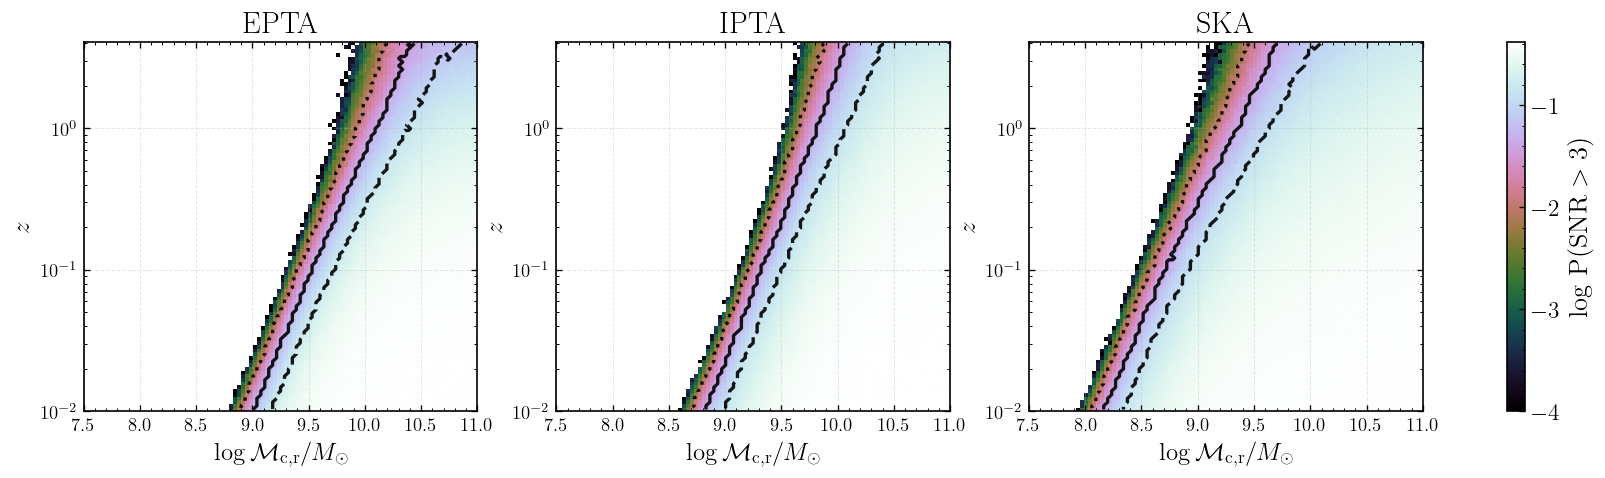

In [8]:
runs = ['EPTA-noRN-logz', 'IPTA-noRN-logz', 'SKA-130-opt-noRN-logz']

# Put to None to use the default SNR_thresh value of 3 used in the original run
SNR_thresh_s = [3, 5, 10]
# SNR thresh to use for the color plot
SNR_TO_SHOW = 3
# Contour of the log efficiency to plot for higher SNR thresholds
LOG_EFF_CONTOUR = -2

lss = ['dotted', 'solid', 'dashed']

fig, axs = plt.subplots(1, 3, figsize=(18, 4))
for i_s, SNR_thresh in enumerate(SNR_thresh_s):
    for ir, run in enumerate(runs):
        # Load run config
        config_file = f"./{results_folder}/{run}/config.yaml"
        with open(config_file, 'r') as file:
            run_config = yaml.safe_load(file)

        # Load efficiency grid
        efficiency_grid = np.load(f"./{results_folder}/{run}/efficiency-grid.npz")
        
        # Get the grid used
        log10_Mcr_mids = efficiency_grid['log10_Mcr_mids']
        z_mids = efficiency_grid['z_mids']

        # Recompute efficiency for SNR_thresh
        SNRs_dict = pickle.load(open(f'{results_folder}/{run}/SNRs_dict.pkl', 'rb'))
        Nc_dict = pickle.load(open(f'{results_folder}/{run}/Nc_dict.pkl', 'rb'))
        efficiency = utils.getEfficiencyFromSNRs(SNRs_dict, Nc_dict,
                                                 SNR_thresh, NP_MIN, 
                                                 log10_Mcr_mids, z_mids)
        
        # If logz is not there it is False
        logz = efficiency_grid.get('logz', False)
        
        # Use the true bin boundaries and a log y-scale
        X, Y = np.meshgrid(log10_Mcr_mids, z_mids)
        
        # Convert to log10 of efficiency
        log_efficiency = np.where(efficiency > 0, 
                                  np.log10(efficiency), 
                                  np.nan)

        # Only plot the contour log_efficiency >= LOG_EFF_CONTOUR
        mask = log_efficiency >= LOG_EFF_CONTOUR
        
        axs[ir].contour(X, Y, mask.T.astype(float),
                        levels=[0.5], 
                        linestyles=lss[i_s],
                        alpha=0.9,
                        colors='k', linewidths=2)
        
        if SNR_thresh == SNR_TO_SHOW:
            # Do the color grid
            pcm = axs[ir].pcolormesh(X, Y, log_efficiency.T, cmap='cubehelix')
        
        if logz:
            axs[ir].set_yscale('log')

        axs[ir].set_xlabel(r'$\log \mathcal{M}_{\mathrm{c,r}} / M_{\odot}$', fontsize=15)
        axs[ir].set_ylabel(r'$z$', fontsize=15)
        axs[ir].set_title(f"{run.split('-')[0]}", fontsize=18)
    
    if SNR_thresh == SNR_TO_SHOW:
        cbar = fig.colorbar(pcm, ax=axs.ravel().tolist())
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(label=fr'$\log$ P$(\mathrm{{SNR}} > {SNR_thresh})$', size=16)

plt.savefig(f"{ref_plot_dir}/log-efficiencies-SNR-{SNR_TO_SHOW}-comp-LEFFc-10{LOG_EFF_CONTOUR}.pdf", 
            bbox_inches='tight')
plt.savefig(f"{ref_plot_dir}/log-efficiencies-SNR-{SNR_TO_SHOW}-comp-LEFFc-10{LOG_EFF_CONTOUR}.png", 
            bbox_inches='tight')
plt.show()
plt.close()

## Average zombie numbers


RESULTS FOR SNR_thresh = 3


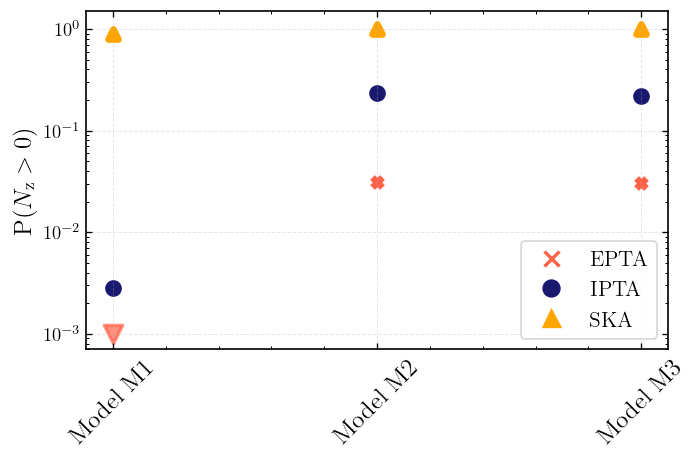


RESULTS FOR SNR_thresh = 5


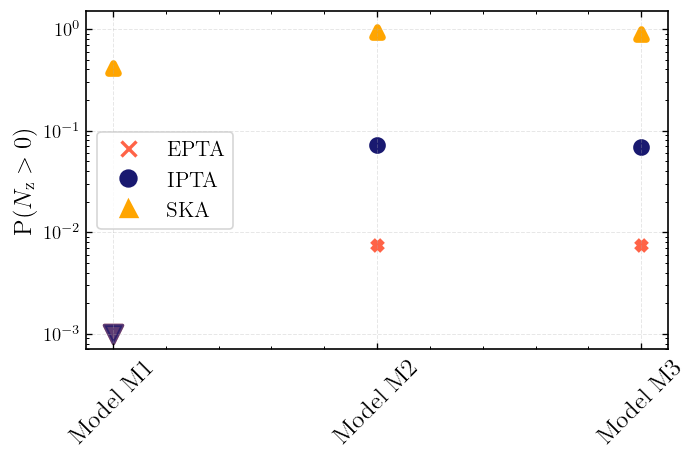


RESULTS FOR SNR_thresh = 10


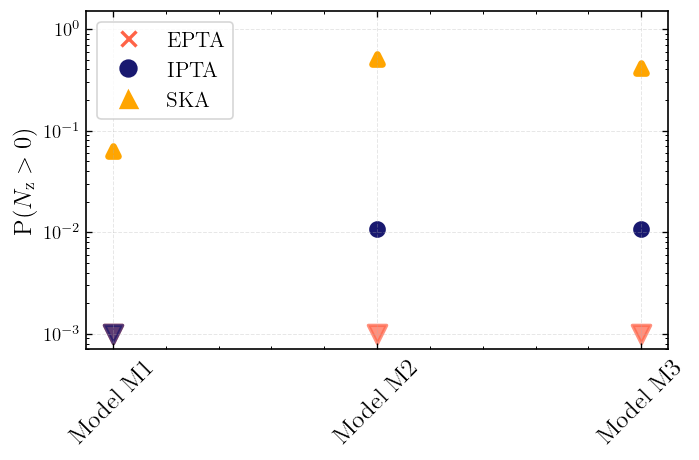


Latex table saved to: ./plots//prob_Nz_table.tex


In [9]:
colors = ['tomato', 'midnightblue', 'orange']
markers = ['x', 'o', '^']
# Probability down to which actually plot the true value
PROB_THRESH = 1e-3
# Put to None to use the default SNR_thresh value of 3 used in the original run
SNR_thresh_s = [3, 5, 10]

Nmodels = len(pop_models)
x_s = np.arange(Nmodels)

# Data storage for all results
results_data = {}  # Structure: results_data[model_idx][snr_thresh][pta_idx] = (prob, Nbar)

for SNR_thresh in SNR_thresh_s:
    print("\nRESULTS FOR SNR_thresh =", SNR_thresh)
    
    # PTA labels to be complete
    pta_labels = []
    
    fig, ax = plt.subplots(figsize=(6,4))
    for i_pta, run in enumerate(runs):
        # Add PTA name used in this run
        pta_labels.append(run.split('-')[0])

        # Load run config
        config_file = f"./{results_folder}/{run}/config.yaml"
        with open(config_file, 'r') as file:
            run_config = yaml.safe_load(file)

        # Load efficiency grid
        efficiency_grid = np.load(f"./{results_folder}/{run}/efficiency-grid.npz")
        
        # Load the grid elements
        log10_Mcr_mids = efficiency_grid['log10_Mcr_mids']
        z_mids = efficiency_grid['z_mids']
        if efficiency_grid.get('logz', False):
            z_edges = efficiency_grid['z_edges']
            Dlogz_s = np.diff(np.log10(z_edges))
            assert np.allclose(Dlogz_s, Dlogz_s[0])
            Dlogz = Dlogz_s[0]
        else:
            Dlogz = None

        # Recompute the efficiciency above our most optimistic detection thresholdency grid
        SNRs_dict = pickle.load(open(f'{results_folder}/{run}/SNRs_dict.pkl', 'rb'))
        Nc_dict = pickle.load(open(f'{results_folder}/{run}/Nc_dict.pkl', 'rb'))
        efficiency = utils.getEfficiencyFromSNRs(SNRs_dict, Nc_dict,
                                                 SNR_thresh, NP_MIN,
                                                 log10_Mcr_mids, z_mids)

        # Load PTA config
        config_file = f"./{results_folder}/{run}/PTA.yaml"
        with open(config_file, 'r') as file:
                PTA = yaml.safe_load(file)
                PTA['Ta_max'] = PTA['Ta_max'] * u.yr

        Nbar_s = np.zeros(Nmodels)

        for ip, pop_model in enumerate(pop_models):
            Nbar_s[ip] = rate.getNbarZombies(pop_model=pop_model, 
                                            efficiency=efficiency,
                                            log10_Mcr_mids=log10_Mcr_mids,
                                            z_mids=z_mids,
                                            Ta_max=PTA['Ta_max'],
                                            fth=run_config['fth'] * u.Hz,
                                            Dlogz=Dlogz)
            

        # Compute probability of at least one event
        prob_det_s = 1 - poisson.pmf(k=0, mu=Nbar_s) # poisson.cdf(k=0, mu=Nbar_s)
        # print(run, prob_det_s, Nbar_s)

        # Store results for table generation
        for ip in range(Nmodels):
            if ip not in results_data:
                results_data[ip] = {}
            if SNR_thresh not in results_data[ip]:
                results_data[ip][SNR_thresh] = {}
            results_data[ip][SNR_thresh][i_pta] = (prob_det_s[ip], Nbar_s[ip])

        for k, x in enumerate(x_s):
            if prob_det_s[k] < PROB_THRESH:
                # Plot downward marker at threshold
                ax.scatter(
                    x, PROB_THRESH,
                    marker='v',          # downward triangle
                    s=120,               # marker size
                    linewidths=2,
                    color=colors[i_pta],
                    edgecolors=colors[i_pta],
                    alpha=0.7
                )
            else:
                # Normal point
                ax.scatter(
                    x, prob_det_s[k],
                    marker=markers[i_pta],
                    linewidths=4,
                    color=colors[i_pta]
                )

    labels = [f"Model M{i+1}" for i in range(Nmodels)]
    ax.set_xticks(x_s, labels, rotation=45, fontsize=15)
    ax.set_ylabel(r"P$(N_{\mathrm{z}} > 0)$", fontsize=15)
    ax.set_yscale('log')
    ax.set_ylim((PROB_THRESH * 0.7, 1.5))

    # Build the legend
    legend_elements = [
        Line2D(
            [0], [0],
            marker=markers[i_pta],
            color=colors[i_pta],
            linestyle='None',
            markersize=9,
            markeredgewidth=2,
            label=pta_labels[i_pta]
        )
        for i_pta in range(len(pta_labels))
    ]

    ax.legend(
        handles=legend_elements,
        fontsize=13,
        loc='best'
    )
    plt.tight_layout()
    plt.savefig(f"./{ref_plot_dir}/Nz-models-PTAs-logz-SNR-{SNR_thresh}.pdf")
    plt.savefig(f"./{ref_plot_dir}/Nz-models-PTAs-logz-SNR-{SNR_thresh}.png")
    plt.show()
    plt.close()

# Create table header with SNR thresholds
snr_thresholds = sorted(results_data[0].keys())

# Build LaTeX table
latex_lines = []
latex_lines.append("\\begin{table*}[h]")
latex_lines.append("\\centering")

# Create column specification
# PTA | M1(6 cols) | M2(6 cols) | M3(6 cols)
# Each model has 3 SNR thresholds × 2 sub-columns (P, N) = 6 columns
ncols_per_model = len(snr_thresholds) * 2  # Each SNR has 2 columns (P, N)
col_spec = "c|" + "|".join([f"{'cc' * len(snr_thresholds)}" for _ in range(Nmodels)])
latex_lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
latex_lines.append("\\toprule")

# Header row 1: PTA and model names (super-columns)
header1 = " "
for model_idx, pop_model in enumerate(pop_models):
    header1 += f" & \\multicolumn{{{ncols_per_model}}}{{c}}{{{pop_model['name']}}}"
header1 += " \\\\"
latex_lines.append(header1)

# Header row 2: SNR thresholds for each model
header2 = ""
for model_idx in range(Nmodels):
    for snr_thresh in snr_thresholds:
        snr_label = f"$\\mathrm{{SNR}}>{snr_thresh if snr_thresh is not None else 3}$"
        header2 += f" & \\multicolumn{{2}}{{c}}{{{snr_label}}}"
header2 += " \\\\"
latex_lines.append(header2)

# Header row 3: P(Nz>0) and <Nz> for each SNR threshold
header3 = ""
for model_idx in range(Nmodels):
    for snr_threshold in snr_thresholds:
        header3 += " & $p_{N_{\\mathrm{z} > 0}}$ & $\\langle N_{\\rm z} \\rangle$"
header3 += " \\\\"
latex_lines.append(header3)
latex_lines.append("\\midrule")

# Data rows: one for each PTA
for i_pta, pta_label in enumerate(pta_labels):
    row = pta_label
    for model_idx in range(Nmodels):
        for snr_thresh in snr_thresholds:
            if i_pta in results_data[model_idx][snr_thresh]:
                prob, nbar = results_data[model_idx][snr_thresh][i_pta]
                # Format: probability to 2 sig figs, Nbar to 2 decimal places
                prob_str = f"{prob:.1e}" if prob < 0.01 else f"{prob:.2f}"
                nbar_str = f"{nbar:.2f}"
                row += f" & {prob_str} & {nbar_str}"
            else:
                row += " & -- & --"
    row += " \\\\"
    latex_lines.append(row)

latex_lines.append("\\bottomrule")
latex_lines.append("\\end{tabular}")
latex_lines.append("\\end{table*}")

# Print LaTeX table
latex_table = "\n".join(latex_lines)

# Save to file
output_file = f"{ref_plot_dir}/prob_Nz_table.tex"
with open(output_file, 'w') as f:
    f.write(latex_table)
print(f"\nLatex table saved to: {output_file}")


## Zombie properties

The PTA should have N_ToAs: 523 ToAs
Using 22 Fourier bins for the red noise.
No red noise in the PTA pulsars.
PTA parameter vector used: {'J2147+0614_NUPPI.1400_efac': 1.0, 'J2147+0614_NUPPI.1400_log10_tnequad': -9.0, 'J2320+0105_NUPPI.1400_efac': 1.0, 'J2320+0105_NUPPI.1400_log10_tnequad': -9.0, 'J2100+2461_NUPPI.1400_efac': 1.0, 'J2100+2461_NUPPI.1400_log10_tnequad': -9.0, 'J0000+1129_NUPPI.1400_efac': 1.0, 'J0000+1129_NUPPI.1400_log10_tnequad': -9.0, 'J1133+5546_NUPPI.1400_efac': 1.0, 'J1133+5546_NUPPI.1400_log10_tnequad': -9.0, 'J1432-5489_NUPPI.1400_efac': 1.0, 'J1432-5489_NUPPI.1400_log10_tnequad': -9.0, 'J1355+1915_NUPPI.1400_efac': 1.0, 'J1355+1915_NUPPI.1400_log10_tnequad': -9.0, 'J0631-4935_NUPPI.1400_efac': 1.0, 'J0631-4935_NUPPI.1400_log10_tnequad': -9.0, 'J1958+2013_NUPPI.1400_efac': 1.0, 'J1958+2013_NUPPI.1400_log10_tnequad': -9.0, 'J0452-4334_NUPPI.1400_efac': 1.0, 'J0452-4334_NUPPI.1400_log10_tnequad': -9.0, 'J2149-0828_NUPPI.1400_efac': 1.0, 'J2149-0828_NUPPI.1400_log

/home/hql/miniconda3/envs/pta-env/lib/python3.11/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/hql/miniconda3/envs/pta-env/lib/python3.11/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


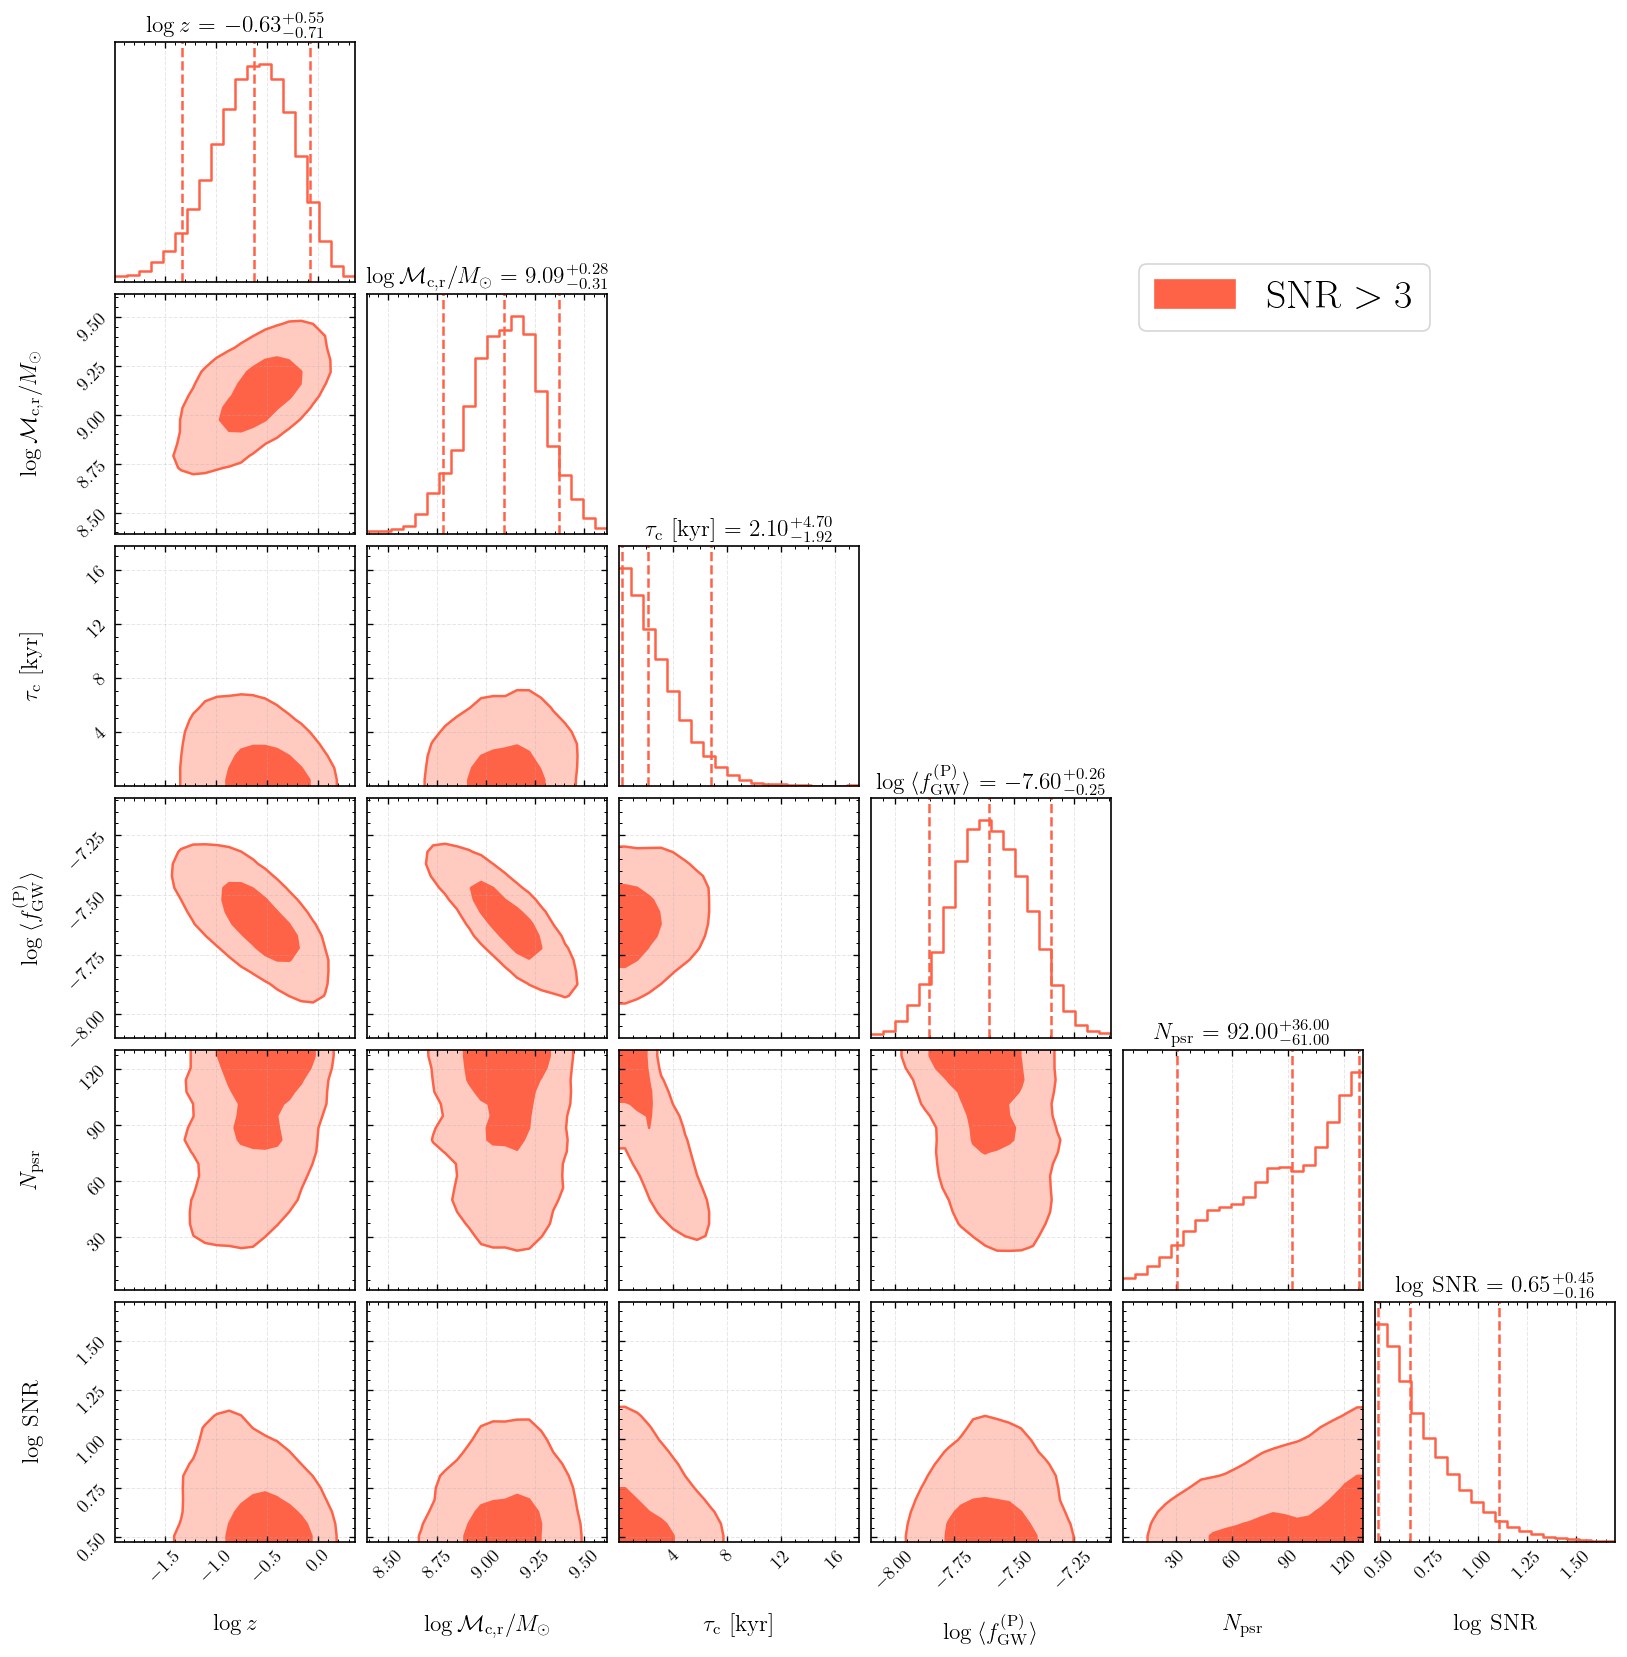

Log-z spacing used, multiply by z...
Maximum probability is: 0.002520296765552499


/home/hql/miniconda3/envs/pta-env/lib/python3.11/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Figure size 780x540 with 0 Axes>

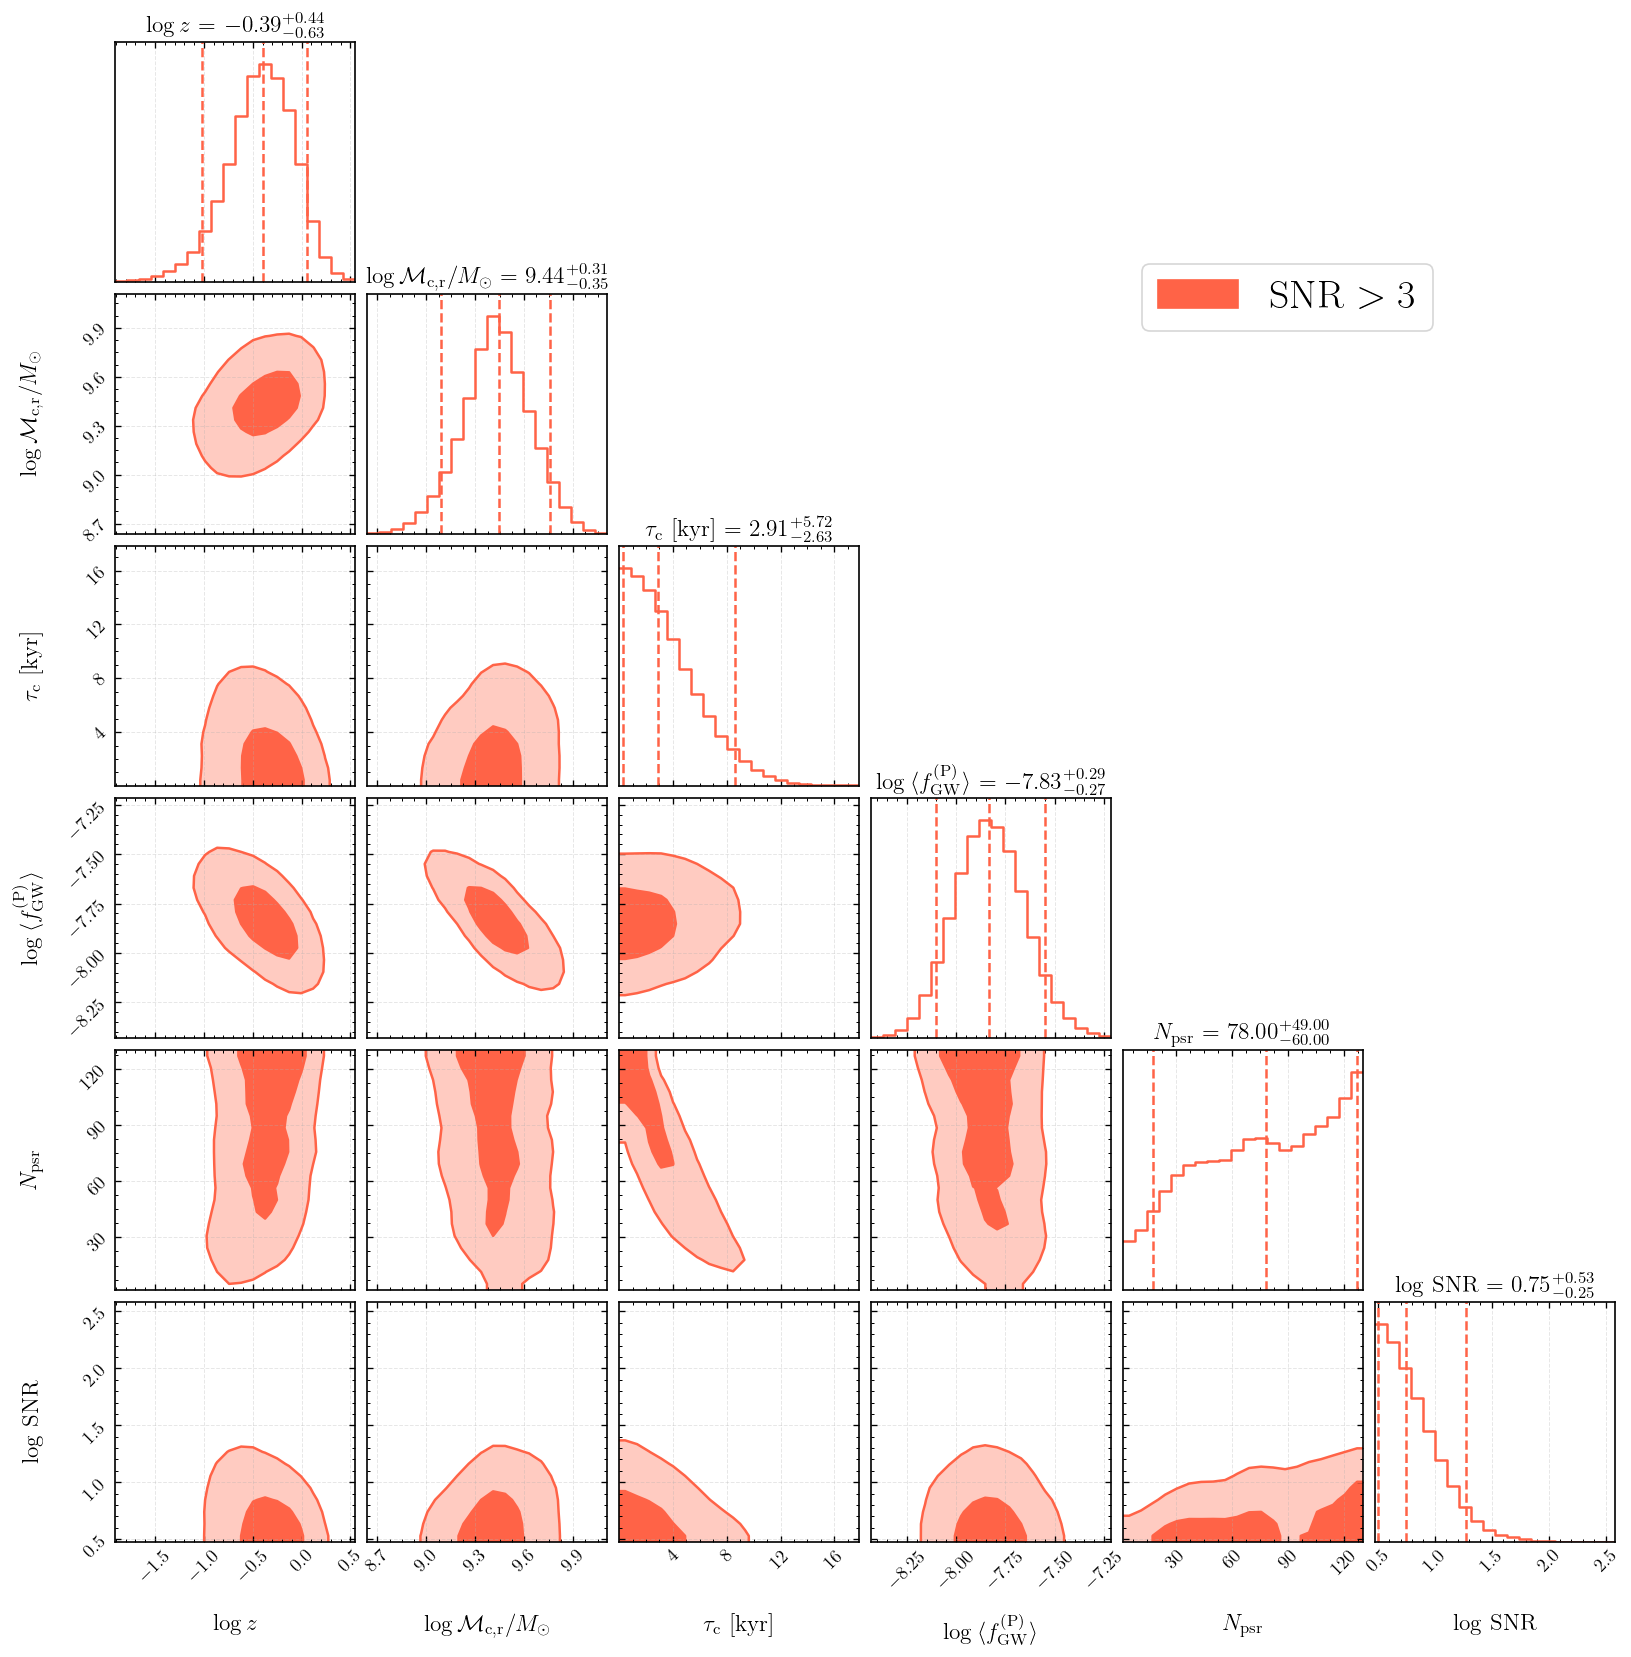

Log-z spacing used, multiply by z...
Maximum probability is: 0.002070653322859615


/home/hql/miniconda3/envs/pta-env/lib/python3.11/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Figure size 780x540 with 0 Axes>

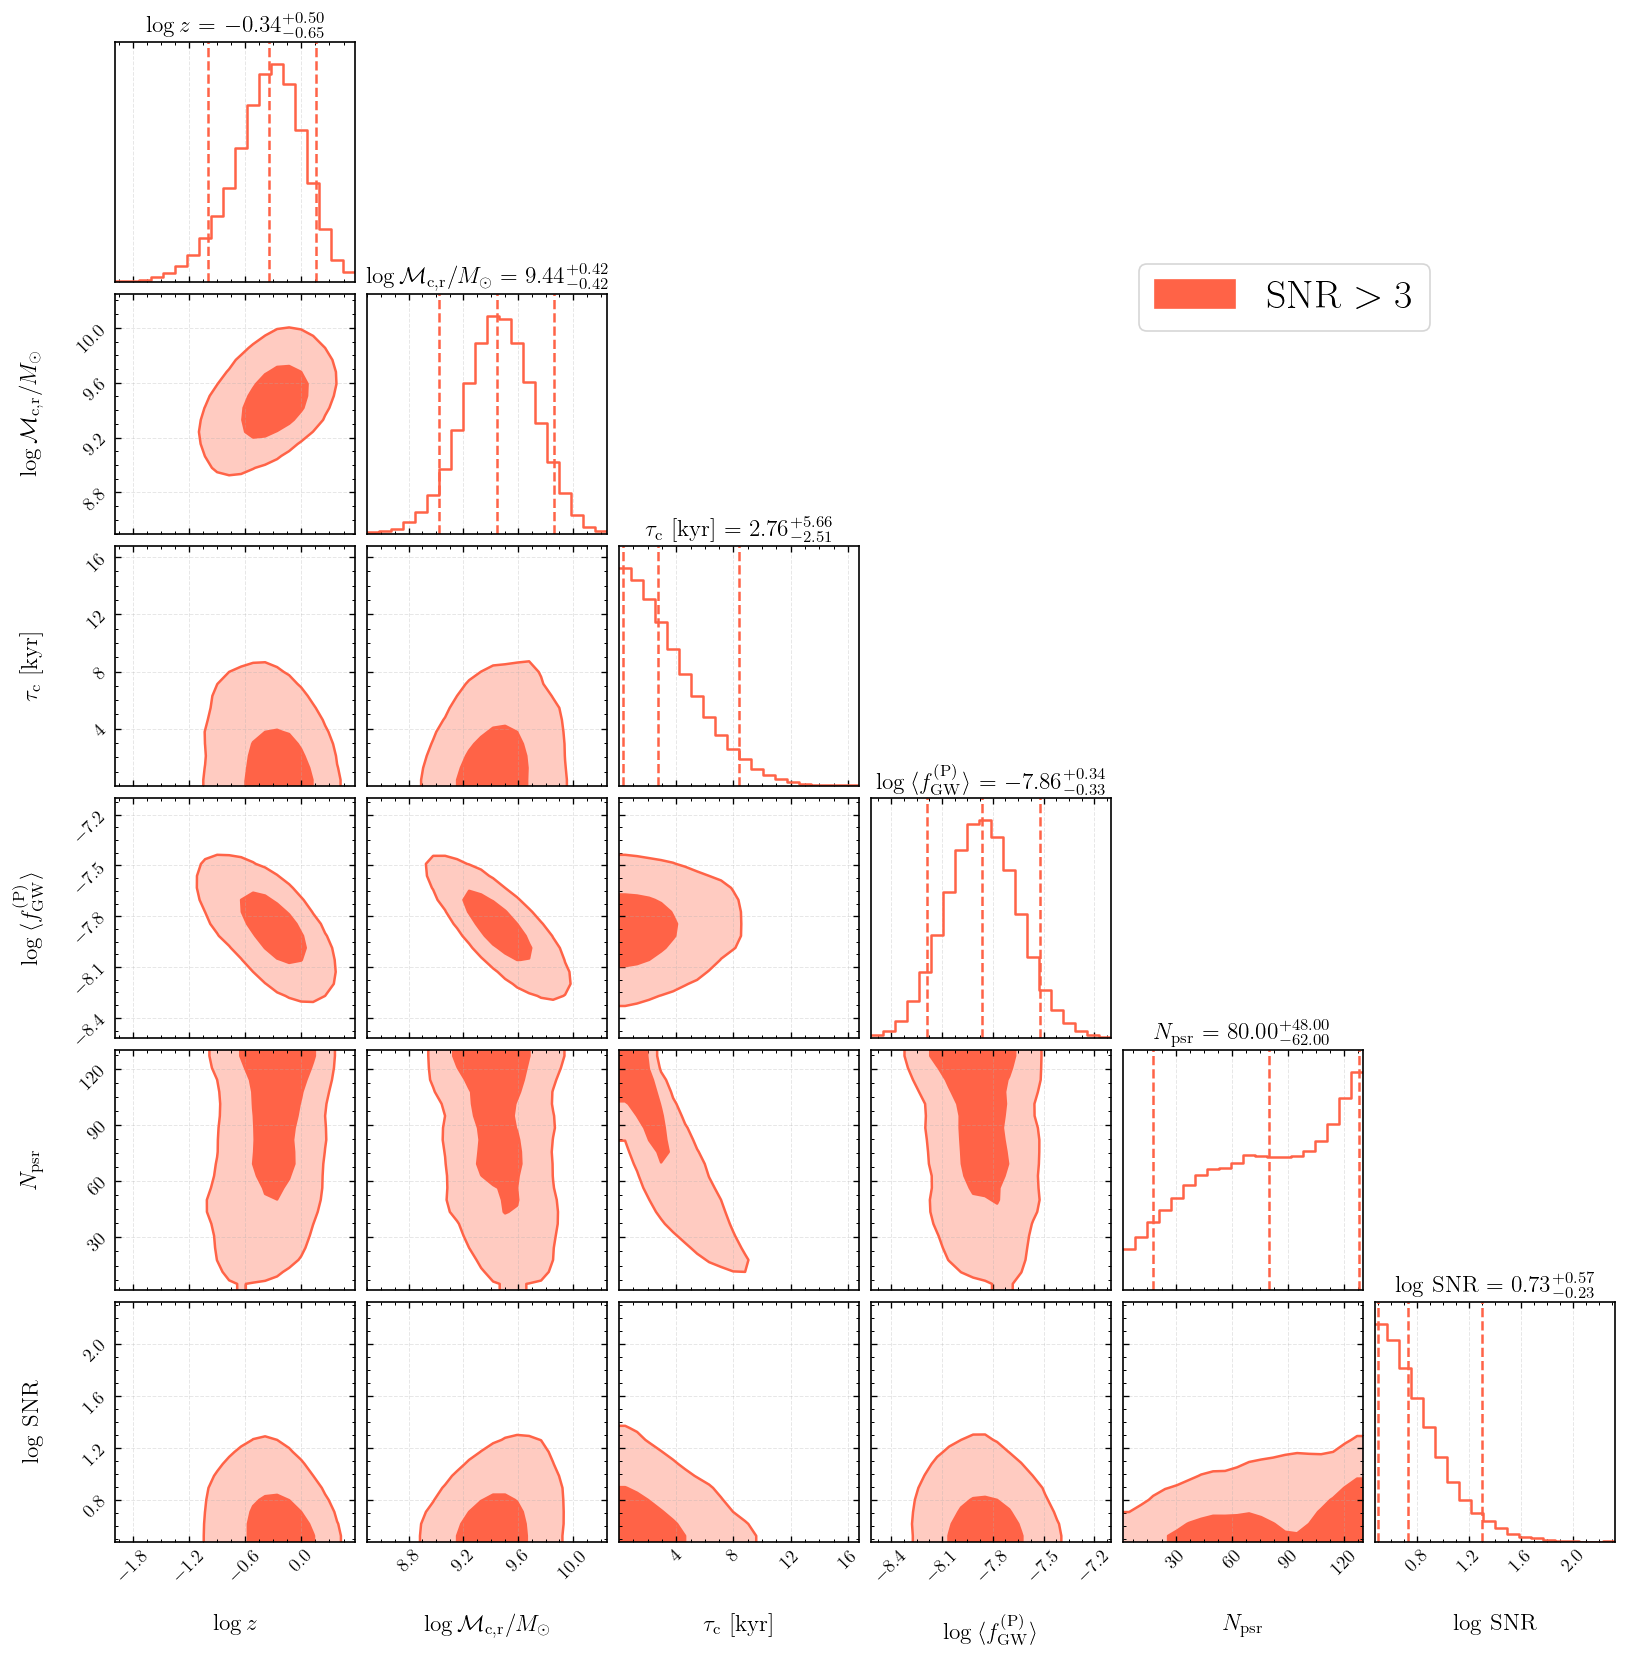

<Figure size 780x540 with 0 Axes>

In [10]:
runs = ['SKA-130-opt-noRN-logz']

# Number of zombies to draw from distribution
N_zombies = 40_000
N_per_chunk = 2000
N_chunk = N_zombies // N_per_chunk

# Get number of population models to test
Nmodels = len(pop_models)

# Fix randomness
seed = 42
rng = np.random.default_rng(seed=seed)

# Store th SNR2 contribution for each run and population model
SNR2s_PSRs_dict = {}

for i_pta, run in enumerate(runs):
        # Load PTA config
        config_file = f"./{results_folder}/{run}/PTA.yaml"
        with open(config_file, 'r') as file:
                PTA = yaml.safe_load(file)

        # Load run config
        config_file = f"./{results_folder}/{run}/config.yaml"
        with open(config_file, 'r') as file:
                run_config = yaml.safe_load(file)

        # Setup the pta object
        pta_utils.setup_pta(run_config=run_config, PTA=PTA)

        # Initialize the dictionary to store the different population models results
        SNR2s_PSRs_dict[i_pta] = {}

        # Load efficiency
        efficiency_grid = np.load(f"./{results_folder}/{run}/efficiency-grid.npz")
        efficiency = efficiency_grid['efficiency']
        log10_Mcr_mids = efficiency_grid['log10_Mcr_mids']
        z_mids = efficiency_grid['z_mids']

        # Construct mesh
        grids = [log10_Mcr_mids, z_mids]
        mesh = np.meshgrid(*grids, indexing='ij')

        # Extract redshift and log_Mcr meshs
        log_Mcr_s, z_s = mesh[0], mesh[1]

        for pop_model in pop_models:
                # Construct the unormalized density over Mcr and z grid
                pop_density = smbhb_density(log10_M=log_Mcr_s,
                                            z=z_s,
                                            **pop_model)
                
                # Weight the SMBHB density by the detection efficiency
                # NOTE: we neglect tau_{c, min} here
                unn_density = (pop_density *
                               Planck18.luminosity_distance(z_s).to(u.Mpc).value ** 2 /
                               ((1 + z_s) ** 2) *
                               efficiency)
                
                if efficiency_grid.get('logz', False):
                        print("Log-z spacing used, multiply by z...")
                        unn_density *= z_s

                # Get samples weighted by efficiency
                samples = utils.sample_from_grid(mesh, unn_density,
                                                 N_samples=N_zombies,
                                                 rng=rng)

                # For each intrinsic sample, generate extrinsic parameters and compute SNR
                log_Mcr_samples, z_samples = samples[:,0], samples[:,1]

                # Store samples (z, Mcr, tauc, cos_theta, phi, cos_inc, avg_forP, Npsr, SNR)
                prop_samples = np.zeros((N_zombies, 9))

                # Store the SNR2s of each pulsar for each zombie
                SNR2_PSRs = np.zeros((N_zombies, PTA['Npsr']))

                for k in range(N_chunk):
                        # Get the chunk slice
                        sl = slice(k*N_per_chunk, (k+1)*N_per_chunk)
                        
                        # Sample extrinsic parameters for this chunk
                        snr2_per_psrs, pars = rate.sampleZombiePars_jax(
                                                        z=z_samples[sl],
                                                        log10_Mcr=log_Mcr_samples[sl],
                                                        q=np.atleast_1d(1),
                                                        PTA=PTA,
                                                        fth=run_config['fth'] * u.Hz,
                                                        N_zombies=N_per_chunk,
                                                        rng=rng)
                        # snr2_per_psrs: (N_chunk, Npsr)
                        assert not np.any(np.isnan(snr2_per_psrs))

                        # Store the sorted snr2 contribution from highest to smallest
                        SNR2_PSRs[sl,:] = np.flip(
                                np.sort(snr2_per_psrs, axis=1),
                                axis=1
                        )

                        # Extract extrinsic pars
                        Delta_tauc = pars['tauc'].to(u.kyr).value
                        cos_theta = pars['cos_theta']
                        phi = pars['phi']
                        cos_inc = pars['cos_inc']
                        log10_fgwP_s = pars['log10_fgwP_s'] # (N_zombies, Npsr)

                        # Identify the valid zombie-pulsar pairs
                        PT_valid_pair = ~np.isnan(log10_fgwP_s)

                        # Get number of pulsars seeing each zombie 
                        N_contrib_psrs = np.sum(PT_valid_pair, axis=-1)

                        # Compute average log_forb_P
                        # NOTE: here, we compute log <fgw_P>, not <log_fgwP>
                        fgwP_s = 10 ** log10_fgwP_s * u.Hz
                        avg_fgwP_s = utils.getAvgOverValids(fgwP_s, 
                                                            N_contrib_psrs, 
                                                            PT_valid_pair).to(u.Hz).value
                        
                        # Compute total SNR for each zombies
                        SNRs = np.sqrt(np.sum(snr2_per_psrs, axis=-1))

                        # Fill the prop_samples array
                        prop_samples[sl,:] = np.array([np.log10(z_samples[sl]), 
                                                       log_Mcr_samples[sl],
                                                       Delta_tauc,
                                                       cos_theta,
                                                       phi,
                                                       cos_inc,
                                                       avg_fgwP_s,
                                                       N_contrib_psrs,
                                                       SNRs]
                        ).T

                ### Store the SNR2s contribution
                SNR2s_PSRs_dict[i_pta][pop_model['name']] = SNR2_PSRs

                ### Plot the corner of prop_samples

                # Select valid zombies i.e.
                # 1. observed by at least NP_MIN pulsar(s)
                # 2. with SNR > 3
                N_contrib_psrs_all = prop_samples[:,7]
                mask = np.where((N_contrib_psrs_all >= NP_MIN) 
                                & (prop_samples[:,-1] > run_config['SNR_thresh'])
                        )[0]
                
                # Mask the samples and SNR2s arrays
                valid_samples = prop_samples[mask,:]
                valid_SNR2_PSRs = SNR2_PSRs[mask,:]

                # Convert fgw to log_fgw
                valid_samples[:,6] = np.log10(valid_samples[:,6])

                # Convert to log10 SNR
                valid_samples[:,-1] = np.log10(valid_samples[:,-1])
                
                # Select columns to show
                to_show = [0, 1, 2, 6, 7, 8]

                weights = np.ones(valid_samples.shape[0]) / valid_samples.shape[0]
                fig = corner.corner(valid_samples[:,to_show], 
                                    labels=[r"$\log z$",
                                            r"$\log \mathcal{M}_{\mathrm{c, r}} / M_\odot$",
                                            r"$\tau_{\mathrm{c}}$ [kyr]",
                                            r"$\log \: \langle f_{\mathrm{GW}}^{\mathrm{(P)}} \rangle$",
                                            r"$N_{\mathrm{psr}}$",
                                            r"$\log$ SNR"],
                        smooth=True, plot_datapoints=False,
                        levels=(0.393, 0.864), # 1 and 2 sigmas contours
                        fill_contours=True,
                        weights=weights,
                        quantiles=[.05, .5, .95],
                        title_quantiles=[.05, .5, .95],
                        title_fmt=".2f",
                        show_titles=True, 
                        color='tomato',
                        smooth1d=True)

                ### Add legend
                patch_bright = mpatches.Patch(color='tomato', 
                                              label=f"SNR $> {run_config['SNR_thresh']}$", 
                                              alpha=1)
                fig.legend(
                        handles=[patch_bright],
                        loc=(0.7, 0.8), # Coordinates in figure fraction (x, y)
                        fontsize=24                
                )

                # Save the figure
                plt.savefig(f"./{ref_plot_dir}/zombie-props-{run.split('-')[0]}-pop-{pop_model['name']}.pdf")
                plt.savefig(f"./{ref_plot_dir}/zombie-props-{run.split('-')[0]}-pop-{pop_model['name']}.png")
                plt.show()
                plt.clf()

## Number of contributing pulsars

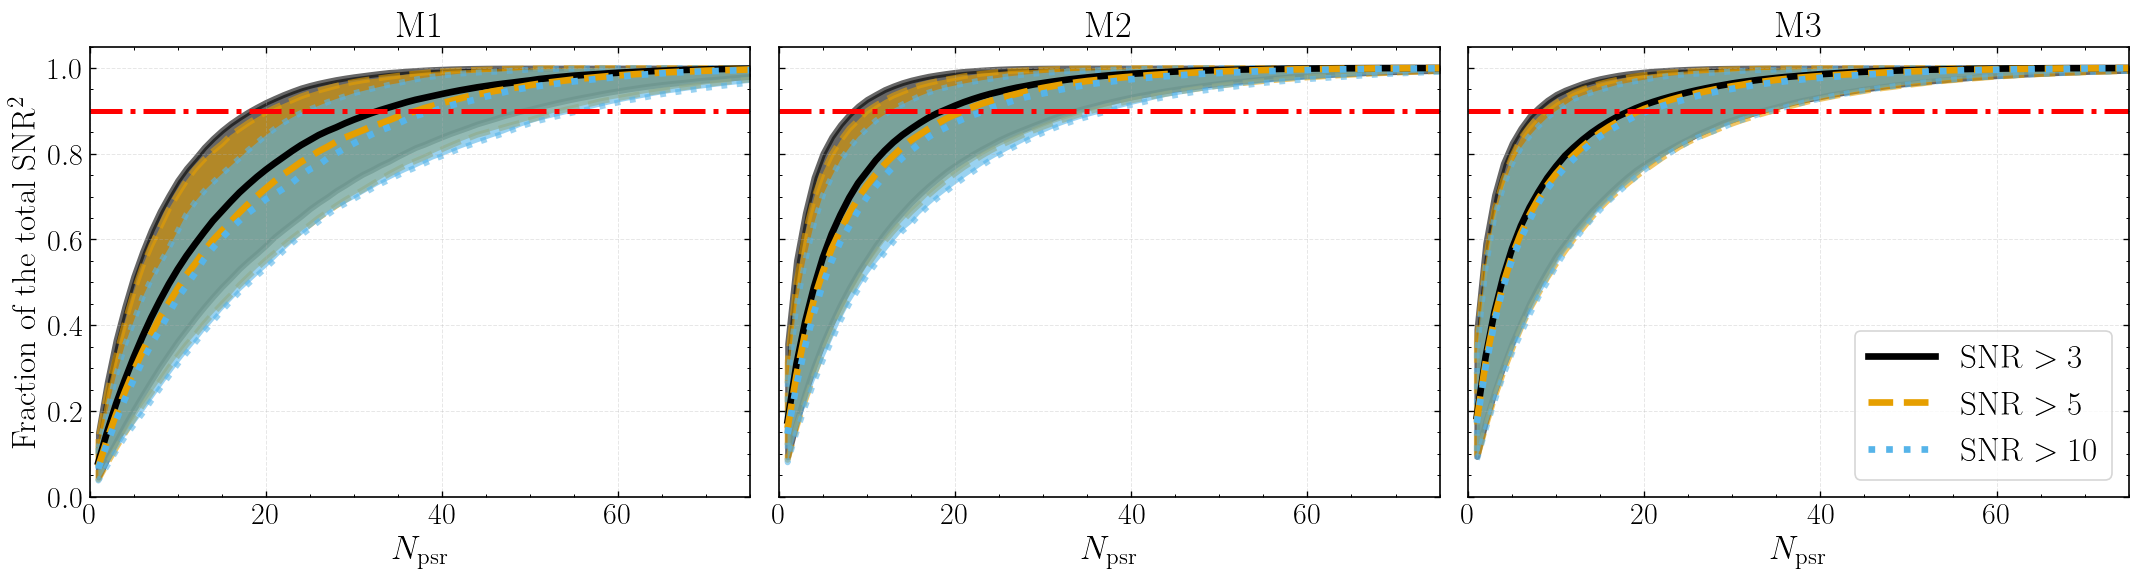

In [13]:
ls = ['solid', '--', 'dotted']
colors = fig_style.COLORBLIND_CYCLE
N_to_show = 75
thresh_s = [3, 5, 10]
Nmodels = len(pop_models)

for i_pta, run in enumerate(runs):
        # Load PTA config
        config_file = f"./{results_folder}/{run}/PTA.yaml"
        with open(config_file, 'r') as file:
                PTA = yaml.safe_load(file)

        x_Npsr = np.arange(1, PTA['Npsr'] + 1)
        
        # Create figure with 3 subplots (one per model)
        fig, axs = plt.subplots(1, Nmodels, figsize=(18, 5), sharey=True)
        if Nmodels == 1:
                axs = [axs]
        
        for im, pop_model in enumerate(pop_models):
                ax = axs[im]
                
                # Extract the array of individual SNR^2 (N_zombies, N_psr)
                SNR2_PSRs = SNR2s_PSRs_dict[i_pta][pop_model['name']]
                
                ### Compute the total SNR2
                SNR2s = np.sum(SNR2_PSRs, axis=1)

                for it, thresh in enumerate(thresh_s):
                        # NOTE: no strong dependence on the SNR threshold
                        # Select above SNR2 threshold
                        mask = SNR2s > (thresh ** 2)

                        if not np.any(mask):
                                continue

                        cumul_SNR2_norm = (np.cumsum(SNR2_PSRs, axis=1)[mask,:] 
                                        / SNR2s[mask,None]).T
                        q_16, q_50, q_84 = np.quantile(cumul_SNR2_norm, 
                                                q=[0.16, 0.5, 0.84], 
                                                axis=1)
                        
                        
                        ax.fill_between(x_Npsr,
                                         y1=q_16, y2=q_84,
                                         linestyle=ls[it],
                                         lw=3.5,
                                         color=colors[it],
                                         alpha=0.6)
                        ax.plot(x_Npsr, 
                                 q_50,
                                 color=colors[it],
                                 linestyle=ls[it],
                                 label=f'SNR $> {thresh}$',
                                 lw=4)
                
                ax.set_xlim((0, N_to_show))
                ax.set_ylim((0, 1.05))
                ax.axhline(y=0.9, ls='-.', lw=3, c='red')
                ax.set_title(f"{pop_model['name']}", fontsize=22)
                ax.set_xlabel(r'$N_{\mathrm{psr}}$', fontsize=20)
                ax.tick_params(axis='x', labelsize=18)
                ax.tick_params(axis='y', labelsize=18)
                if im == 0:
                        ax.set_ylabel(r'Fraction of the total SNR$^2$', fontsize=20)
                if im == Nmodels - 1:
                        ax.legend(fontsize=20)
        plt.tight_layout()
        plt.savefig(f"{ref_plot_dir}/cumul_SNR2_PTA_{PTA['psrs_pos']}_3cols.png", bbox_inches='tight')
        plt.savefig(f"{ref_plot_dir}/cumul_SNR2_PTA_{PTA['psrs_pos']}_3cols.pdf", bbox_inches='tight')
        plt.show()
        plt.close(fig)